# 25 &middot; Modal Muscle Actuation

How does a soft creature *move itself*? Not with painted muscle fibers or a hand-rigged
skeleton, but with **its own natural vibration modes used as muscles**, the idea behind
*Modal Muscles* / *Actuators à la Mode* ([Benchekroun et&nbsp;al.](https://www.dgp.toronto.edu/projects/)).
A linear modal analysis of the shape gives a few displacement modes $D$. Dialing their
amplitudes $\mathbf a$ sets, per element, a rest target that the flesh tries to match while
passive ARAP elasticity and inertia resist, and everything is simulated in a
skinning-eigenmode subspace $\mathbf x = B\,\mathbf z$. We float a four-legged caterpillar in
space, then drop it on the ground and wiggle its muscles into a gait.

Imports, and every tunable parameter of this notebook.

In [1]:
%matplotlib inline
import os
import warnings
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import igl
import simkit
from simkit.clustered_plastic_stretch_tensor import clustered_plastic_stretch_tensor
from simkit.fast_sandwich_transform_clustered import fast_sandwich_transform_clustered
import utils

# dense products on some numpy / Accelerate builds raise spurious floating-point flags; the results are exact
warnings.filterwarnings("ignore", message=".*encountered in (matmul|clustered_ARBs)")

NOTEBOOK = "025_modal_muscle_actuation"                          # this file's name
RESULTS_DIR = utils.notebook_results_path(NOTEBOOK)  # results/025_modal_muscle_actuation/
MEDIA_DIR = "media"                                              # tracked copies for the website
# caterpillar mesh
NX, NY = 70, 34                       # background grid vertices
WIDTH, HEIGHT = 4.0, 2.0              # background grid size (normalized to [-1, 1] afterwards)
BODY_FRAC = 0.34                      # share of the height taken by the body bar
N_LEGS = 4                            # legs hanging below the bar
LEG_FRAC = 0.5                        # share of the width covered by legs
# muscles and reduced model
N_RIGID = 3                           # rigid modes in 2D (2 translations + 1 rotation), dropped
N_MUSCLES = 4                         # deformation modes kept as muscles
N_SKINNING_MODES = 8                  # skinning eigenmodes spanning the subspace B
N_CLUSTERS = 20                       # passive rotation clusters (spectral cubature)
MAX_GRAD_D = 2.0                      # muscle ceiling: largest per-triangle |grad(a_k d_k)|_F
MODE_VIS = 0.35                       # largest vertex displacement when drawing a mode
RHO = 1e3                             # density
BCD_ITERS = 10                        # local/global iterations per time step
BCD_TOL = 1e-6                        # ... or fewer, once |z_new - z| < BCD_TOL
# floating experiment
MU_FLOAT, GAMMA_FLOAT = 1e5, 1e5      # passive (ARAP) / active (muscle) stiffness
DT_FLOAT = 0.02                       # time step (s)
N_STEPS_FLOAT = 180                   # time steps
AMP_FLOAT = np.array([0.9, 0.6, 0.0, 0.0])      # muscle amplitudes, as a fraction of each ceiling
PERIOD_FLOAT = np.array([1.0, 0.7, 1.0, 1.0])   # seconds per cycle
PHASE_FLOAT = np.array([0.0, 0.25, 0.0, 0.0])   # fraction of a period
# crawling experiment
MU_CRAWL, GAMMA_CRAWL = 1e6, 1e6      # passive / active stiffness
DT_CRAWL = 1e-2                       # time step (s)
N_STEPS_CRAWL = 450                   # time steps
GRAVITY = -9.8                        # vertical acceleration
N_CONTACT = 30                        # boundary vertices that can touch the ground
GROUND_GAP = 0.15                     # the ground sits this far below the feet at rest
FRICTION = 1.0                        # share of a contact point's sliding velocity removed (1 sticks, 0 slides)
AMP_FRAC = np.array([0.45, 0.35, 0.25, 0.15])   # the gait (edit me): amplitudes, fraction of the ceiling
PERIODS = np.array([1.20, 0.80, 1.00, 0.60])    # seconds per cycle
PHASES = np.array([0.00, 0.25, 0.50, 0.10])     # fraction of a period
# validation
SEED = 0                              # RNG seed of the gradient-check state
FD_NOISE = 0.05                       # perturbation of the reduced state at the gradient check
FD_STEP = 1e-6                        # central-difference step
BCD_DEMO_ITERS = 30                   # local/global iterations in the convergence plot
BCD_DEMO_AMP = 0.5                    # muscle activation (fraction of the ceiling) in that plot
# optional CMA-ES gait search (off by default: it runs many rollouts)
RUN_CMA = False                       # set True to optimize the gait
CMA_ROLLOUT_STEPS = 150               # time steps per candidate gait
CMA_GENERATIONS = 4                   # CMA-ES generations
CMA_POPSIZE = 6                       # candidates per generation
CMA_SIGMA = 0.2                       # initial search radius
CMA_PERIOD_RANGE = (0.4, 1.5)         # allowed periods (s)
# animation
FPS = 24                              # video frame rate
STRIDE_FLOAT, STRIDE_CRAWL = 3, 5     # draw every k-th time step
CATERPILLAR_FACE, CATERPILLAR_EDGE = "#a1d99b", "#00441b"

## A creature, not a rectangle

A horizontal body bar with four stubby legs, triangulated from scratch: lay a libigl grid over
the bounding box, keep the grid cells (two triangles each) whose center falls inside the bar or a
leg, and drop the vertices no triangle uses (`igl.remove_unreferenced`). The result is one
conforming mesh, which `simkit.normalize_and_center` scales into $[-1,1]$. The whole body is free:
no pins, no handles.

1676 vertices, 3014 triangles


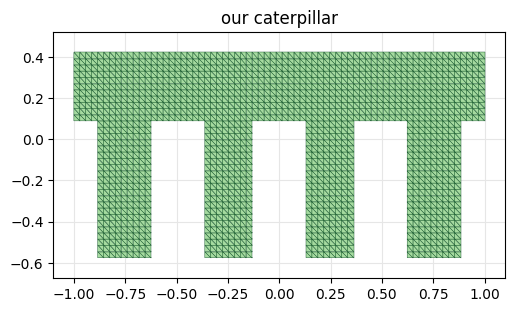

In [2]:
V, F = igl.triangulated_grid(NX, NY)                         # unit square, NX x NY vertices
V = V * np.array([WIDTH, HEIGHT])                            # WIDTH x HEIGHT box
cell_center = (V[F].min(axis=1) + V[F].max(axis=1)) / 2     # shared by a cell's two triangles
body_y0 = HEIGHT * (1 - BODY_FRAC)                           # bottom of the body bar
in_body = cell_center[:, 1] >= body_y0
leg_x = WIDTH / N_LEGS * (np.arange(N_LEGS) + 0.5)           # leg centers
in_leg = (np.abs(cell_center[:, [0]] - leg_x) <= WIDTH * LEG_FRAC / N_LEGS / 2).any(axis=1)
in_leg &= cell_center[:, 1] < body_y0
X, T, _, _ = igl.remove_unreferenced(V, F[in_body | in_leg])
X = simkit.normalize_and_center(X)
n, dim = X.shape
print(f"{n} vertices, {T.shape[0]} triangles")

fig, ax = plt.subplots(figsize=(6, 3.2))
utils.plot_mesh(ax, X, T, facecolor=CATERPILLAR_FACE, edgecolor=CATERPILLAR_EDGE, lw=0.3,
                title="our caterpillar")
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "mesh.png"),
                              copy_to=os.path.join(MEDIA_DIR, "025_mesh.png"))
plt.show()

## How does this shape *naturally* move?

Pluck the creature and it rings in its **natural vibration modes**, the eigenvectors of
$K\,\mathbf d = \lambda M\,\mathbf d$ with $K$ the elastic stiffness and $M$ the mass matrix.
`simkit.linear_modal_analysis` returns them ordered by eigenvalue (frequency²). The first
`N_RIGID` eigenvalues are zero up to round-off: the rigid modes (two translations and a rotation)
that move the shape without deforming it. They store no elastic energy and make useless muscles,
so we drop them and keep the next `N_MUSCLES`. The bar chart shows the gap.

eigenvalues (frequency^2):
  mode 0:  -6.8127e-13  <- rigid (approx 0)
  mode 1:  -3.3108e-13  <- rigid (approx 0)
  mode 2:  -7.3447e-14  <- rigid (approx 0)
  mode 3:   1.2521e-01  <- muscle mode
  mode 4:   3.0175e-01  <- muscle mode
  mode 5:   3.6617e-01  <- muscle mode
  mode 6:   8.1365e-01  <- muscle mode


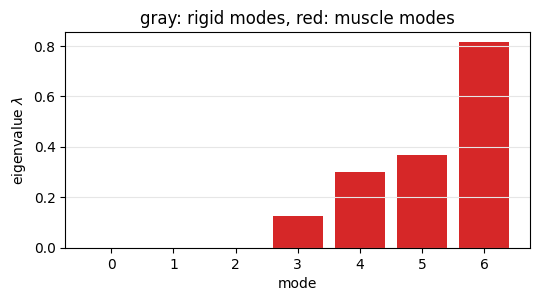

In [3]:
eigvals, D = simkit.linear_modal_analysis(X, T, N_RIGID + N_MUSCLES)
modeset = list(range(N_RIGID, N_RIGID + N_MUSCLES))         # [3, 4, 5, 6]
D_muscles = D[:, modeset]

print("eigenvalues (frequency^2):")
for i, lam_i in enumerate(eigvals):
    tag = "  <- rigid (approx 0)" if i < N_RIGID else "  <- muscle mode"
    print(f"  mode {i}:  {lam_i: .4e}{tag}")

fig, ax = plt.subplots(figsize=(6, 2.8))
ax.bar(range(len(eigvals)), eigvals, color=["0.6"] * N_RIGID + ["#d62728"] * N_MUSCLES)
ax.set(xlabel="mode", ylabel=r"eigenvalue $\lambda$", title="gray: rigid modes, red: muscle modes")
ax.grid(True, axis="y", color="0.9")
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "eigenvalues.png"),
                              copy_to=os.path.join(MEDIA_DIR, "025_eigenvalues.png"))
plt.show()

### The first four muscle modes

Each panel pushes the rest shape (gray) along one mode, scaled so its largest vertex
displacement is `MODE_VIS`, and colors it by the mode's displacement magnitude
$\lVert\mathbf d_k\rVert$ per vertex. These four whole-body fields are the creature's entire
**muscle vocabulary**, obtained without a rig or painted fibers.

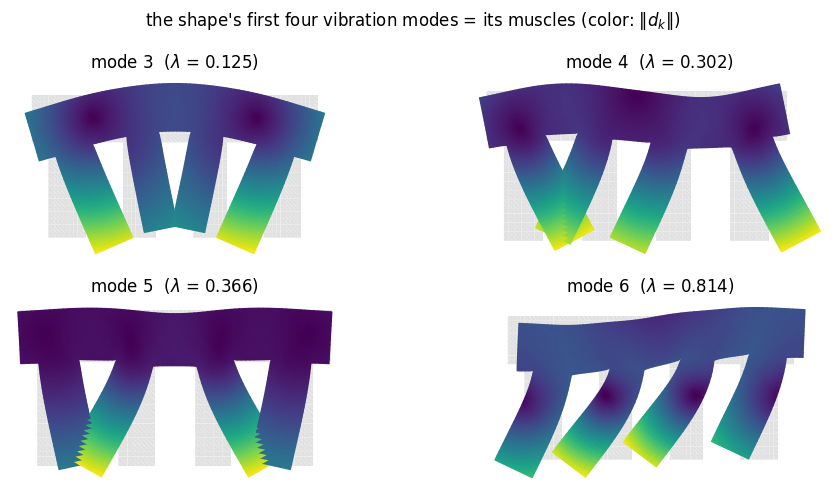

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(10, 5))
for ax, k in zip(axes.ravel(), modeset):
    d_k = D[:, k].reshape(n, dim)
    mag = np.linalg.norm(d_k, axis=1)
    X_k = X + MODE_VIS / mag.max() * d_k
    utils.PolyMeshArtist(ax, X, T, facecolor="0.88", edgecolor="none", lw=0, zorder=1)
    utils.plot_scalar_field(ax, X_k, T, mag, cmap="viridis", edges=False, colorbar=False,
                            lims=utils.auto_limits([X, X_k], pad=0.05),
                            title=f"mode {k}  ($\\lambda$ = {eigvals[k]:.3f})")
    ax.axis("off")
fig.suptitle(r"the shape's first four vibration modes = its muscles (color: $\|d_k\|$)")
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "modes.png"),
                              copy_to=os.path.join(MEDIA_DIR, "025_modes.png"))
plt.show()

## Building the reduced model

Three reduced ingredients, built once. **`B`** is the skinning-eigenmode subspace
(`simkit.skinning_eigenmodes`, mass-orthonormalized): the simulation only ever solves for
$\mathbf z$ with $\mathbf x = B\mathbf z$. **`D_act`** holds the muscle modes plus the rest pose
as a last column, so the activation $\mathbf a = (a_1,\dots,a_4, 1)$ describes the target shape
$\mathbf y = D_{\text{act}}\mathbf a = X + \sum_i a_i\mathbf d_i$. **`labels`** groups the
triangles into `N_CLUSTERS` spectral-cubature clusters that share one passive rotation, while the
muscles use a single rotation for the whole body. `simkit.limit_actuation_dirichlet_energy` gives
each muscle an amplitude ceiling, `MAX_GRAD_D` over its largest per-triangle displacement gradient
$\lVert\nabla\mathbf d_k\rVert_F$, and all commands below are fractions of it.

In [5]:
W_skin, _, B = simkit.skinning_eigenmodes(X, T, N_SKINNING_MODES)
B = simkit.orthonormalize(B, M=sp.sparse.kron(simkit.massmatrix(X, T), sp.sparse.identity(dim)))
D_act = np.hstack([D_muscles, X.reshape(-1, 1)])            # muscles + rest pose
_, _, labels = simkit.spectral_cubature(X, T, W_skin, N_CLUSTERS, return_labels=True)
labels_active = np.zeros(len(T), dtype=int)                  # a single active cluster
limit_a = simkit.limit_actuation_dirichlet_energy(X, T, D, max_s=MAX_GRAD_D)[modeset]
print(f"subspace dim = {B.shape[1]},  muscles = {N_MUSCLES},  clusters = {N_CLUSTERS}")
print("per-muscle amplitude ceiling:", np.round(limit_a, 3))

subspace dim = 48,  muscles = 4,  clusters = 20
per-muscle amplitude ceiling: [0.48  0.412 0.288 0.244]


The scalar fields behind that model: the eight skinning weights $w_k$ (red positive, blue negative;
each spans $\dim\times(\dim+1) = 6$ columns of $B$, an affine map per weight) and the passive rotation
clusters. $w_0$ is constant, so $B$ contains every affine motion, and higher weights vary faster.

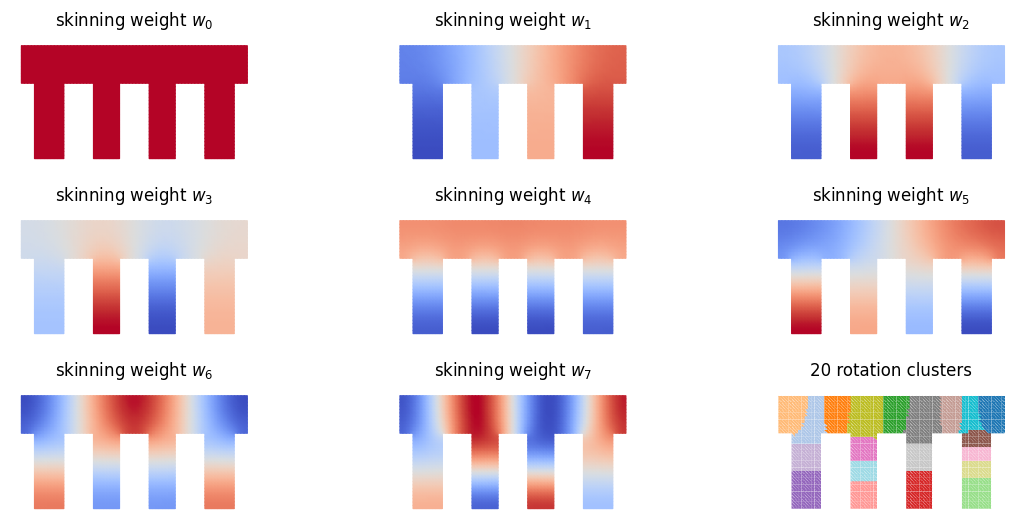

In [6]:
fig, axes = plt.subplots(3, 3, figsize=(12, 5.4))
for k, ax in enumerate(axes.ravel()[:N_SKINNING_MODES]):
    w_max = np.abs(W_skin[:, k]).max()
    utils.plot_scalar_field(ax, X, T, W_skin[:, k], cmap="coolwarm", vmin=-w_max, vmax=w_max,
                            edges=False, colorbar=False, title=f"skinning weight $w_{k}$")
    ax.axis("off")
utils.plot_scalar_field(axes[2, 2], X, T, labels, cmap="tab20", edges=False, colorbar=False,
                        title=f"{N_CLUSTERS} rotation clusters")
axes[2, 2].axis("off")
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "subspace.png"),
                              copy_to=os.path.join(MEDIA_DIR, "025_subspace.png"))
plt.show()

And the field behind the ceilings: the per-triangle displacement gradient
$\lVert\nabla\mathbf d_k\rVert_F$ of each muscle mode. It peaks in the swinging legs, and the
ceiling scales the mode until that peak reaches `MAX_GRAD_D`, so the higher modes, with steeper
peaks, get lower ceilings.

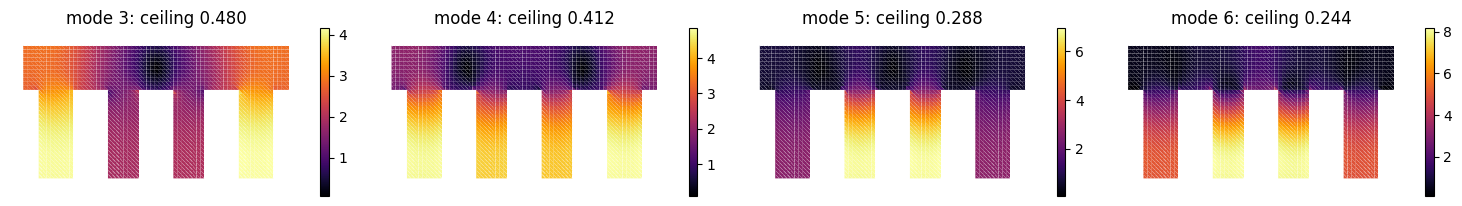

In [7]:
J = simkit.deformation_jacobian(X, T)
grad_d = np.linalg.norm((J @ D_muscles).reshape(len(T), dim * dim, N_MUSCLES), axis=1)
fig, axes = plt.subplots(1, N_MUSCLES, figsize=(15, 2.4))
for j, ax in enumerate(axes):
    utils.plot_scalar_field(ax, X, T, grad_d[:, j], cmap="inferno", edges=False,
                            title=f"mode {modeset[j]}: ceiling {limit_a[j]:.3f}")
    ax.axis("off")
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "mode_stretch.png"),
                              copy_to=os.path.join(MEDIA_DIR, "025_mode_stretch.png"))
plt.show()

## Constant operators

Everything the time steps need, precomputed in the subspace. `JB` and `JY` map $\mathbf z$ and
$\mathbf a$ to per-triangle deformation gradients $F_e$ and $Y_e$. `L_B` is the reduced,
area-weighted Dirichlet stiffness $B^\top J^\top V J B$. `C_passive` sums $v_e F_e$ per cluster,
whose polar factor is that cluster's best-fit rotation. `K_active` returns $\sum_e v_e F_e Y_e^\top$,
the matrix whose polar factor is the muscles' best-fit rotation, and `fst(R)` returns
$B^\top J^\top V\,(R\,Y)$ as a matrix acting on $\mathbf a$ (both are precomputed bilinear tensors
from simkit). `BMB` is the reduced mass, `f_gravity` the reduced weight, and
`(z_rest, a_rest)` the rest pose projected into both subspaces.

In [8]:
vol = simkit.volume(X, T)
JB = J @ B                                                  # z -> stacked F_e
JY = J @ D_act                                              # a -> stacked Y_e
V_e = sp.sparse.kron(sp.sparse.diags(vol.ravel()), sp.sparse.identity(dim * dim))
L_B = JB.T @ (V_e @ JB)
G, _ = simkit.cluster_grouping_matrices(labels, X, T)
C_passive = sp.sparse.kron(G @ sp.sparse.diags(vol.ravel()), sp.sparse.identity(dim * dim)) @ JB
K_active = clustered_plastic_stretch_tensor(X, T, labels_active, B, D_act, w=vol)
fst = fast_sandwich_transform_clustered(JB.T @ V_e, JY, labels_active, dim=dim)
M = sp.sparse.kron(simkit.massmatrix(X, T, rho=RHO), sp.sparse.identity(dim))
BMB = B.T @ M @ B
f_gravity = B.T @ simkit.gravity_force(X, T, a=GRAVITY, rho=RHO).reshape(-1, 1)
z_rest = simkit.project_into_subspace(X.reshape(-1, 1), B, M=M, BMB=BMB)
a_rest = simkit.project_into_subspace(X.reshape(-1, 1), D_act, M=M)
print(f"L_B {L_B.shape}, C_passive {C_passive.shape}, a_rest = {np.round(a_rest.ravel(), 6) + 0.0}")

L_B (48, 48), C_passive (80, 48), a_rest = [0. 0. 0. 0. 1.]


## The modal-muscle system

`modal_muscle_system` returns the objective $E$ of one backward-Euler step, its gradient and its
Hessian, plus the two steps of the block-coordinate solver `simkit.solvers.block_coord`. The
**local step** finds the best rotations $R$ by polar decomposition (one per passive cluster $l_e$,
one for the muscles). With the rotations frozen $E$ is quadratic in $\mathbf z$ with the constant
Hessian $H = (\mu+\gamma)L_B + B^\top M B/h^2$, so the **global step** is one Cholesky solve.
Because the rotations are optimal, the gradient of $E$ equals its frozen-rotation gradient, and
`hessian_func` returns $H$, the matrix the global step factors. An optional `contact` callable adds
a ground force inside the global step (later). With $\tilde{\mathbf z} = 2\mathbf z_{\text{curr}}-\mathbf z_{\text{prev}}$,

$$
E(\mathbf z) = \min_{R}\;
\underbrace{\tfrac{\mu}{2}\sum_e v_e\lVert F_e - R_{l_e}\rVert^2}_{\text{passive ARAP}}
+ \underbrace{\tfrac{\gamma}{2}\sum_e v_e\lVert F_e - R^{a} Y_e(\mathbf a)\rVert^2}_{\text{muscles}}
+ \underbrace{\tfrac{1}{2h^2}\lVert \mathbf z-\tilde{\mathbf z}\rVert^2_{B^\top\! M B}}_{\text{inertia}}
- \mathbf f_{\text{ext}}^\top\mathbf z .
$$

In [9]:
def modal_muscle_system(z_curr, z_prev, a, mu, gamma, h, f_ext, contact=None):
    """Passive clustered ARAP + modal muscles + inertia + external force, in reduced coordinates z."""
    Y = (JY @ a).reshape(-1, dim, dim)                      # per-triangle muscle targets
    z_tilde = simkit.energies.be_target(z_curr, z_prev, h)  # inertial target z + h v
    H_passive = mu * L_B
    H_active = gamma * L_B
    H_inertia = simkit.energies.kinetic_hessian_be(BMB, h)
    H_total = H_passive + H_active + H_inertia
    chol_H = sp.linalg.cho_factor(H_total)

    def local_step(z):
        R_passive = simkit.polar_svd((C_passive @ z).reshape(-1, dim, dim))[0]
        R_active = simkit.polar_svd(K_active(z, a))[0]
        return R_passive, R_active

    def global_step(z, R):
        R_passive, R_active = R
        f_passive = mu * C_passive.T @ R_passive.reshape(-1, 1)
        f_active = gamma * fst(R_active) @ a
        f_inertia = BMB @ z_tilde / h**2
        f_free = f_passive + f_active + f_inertia + f_ext
        f_contact = 0.0 if contact is None else contact(z, z_curr, f_free, chol_H, h)
        f_total = f_free + f_contact
        z_new = sp.linalg.cho_solve(chol_H, f_total)
        return z_new

    def energy_func(z):
        Fz = (JB @ z).reshape(-1, dim, dim)
        R_passive, R_active = local_step(z)
        E_passive = 0.5 * mu * np.sum(vol.ravel() * np.sum((Fz - R_passive[labels]) ** 2, axis=(1, 2)))
        E_active = 0.5 * gamma * np.sum(vol.ravel() * np.sum((Fz - R_active[labels_active] @ Y) ** 2, axis=(1, 2)))
        E_inertia = simkit.energies.kinetic_energy_be(z, z_curr, z_prev, BMB, h)
        E_external = -(f_ext.T @ z).item()
        E_total = E_passive + E_active + E_inertia + E_external
        return E_total

    def gradient_func(z):
        R_passive, R_active = local_step(z)
        g_passive = mu * (L_B @ z - C_passive.T @ R_passive.reshape(-1, 1))
        g_active = gamma * (L_B @ z - fst(R_active) @ a)
        g_inertia = simkit.energies.kinetic_gradient_be(z, z_curr, z_prev, BMB, h)
        g_external = -f_ext
        g_total = g_passive + g_active + g_inertia + g_external
        return g_total

    def hessian_func(z):
        return H_total

    return energy_func, gradient_func, hessian_func, local_step, global_step

Two checks before simulating, with the crawling stiffness and gravity. First, a central-difference
check of `gradient_func` at a perturbed state with random muscle activations and a nonzero velocity.
Second, `BCD_DEMO_ITERS` local/global iterations of one step from rest with every muscle at
`BCD_DEMO_AMP` of its ceiling (`BCD_ITERS`, dashed, is what the simulations use). Left: the energy
decreases monotonically, as block-coordinate descent guarantees. Right: the gradient norm falls
linearly on the log scale, but slowly (about two orders of magnitude in `BCD_ITERS` iterations):
the price of a constant $H$ that is factored once.

relative gradient error |g_fd - g| / |g| = 7.16e-11


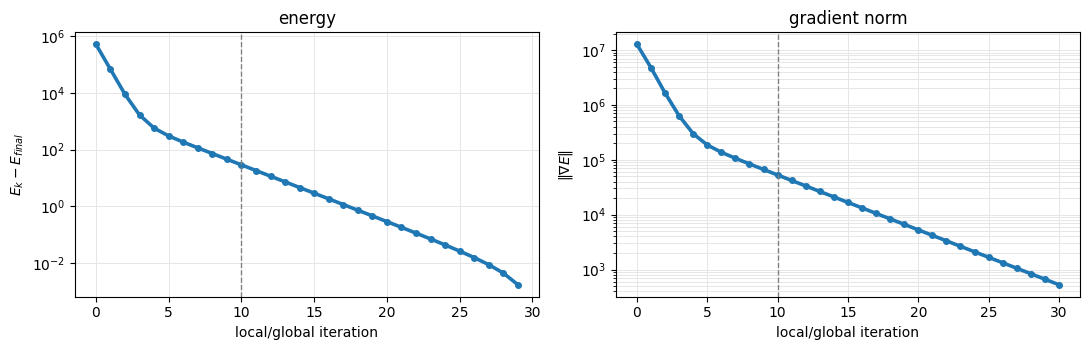

In [10]:
rng = np.random.default_rng(SEED)
a_test = a_rest.copy()
a_test[:-1, 0] = limit_a * rng.uniform(-1, 1, N_MUSCLES)
z_test = z_rest + FD_NOISE * rng.standard_normal(z_rest.shape)
energy_func, gradient_func, hessian_func, local_step, global_step = modal_muscle_system(
    z_rest, z_rest - FD_NOISE * rng.standard_normal(z_rest.shape), a_test,
    MU_CRAWL, GAMMA_CRAWL, DT_CRAWL, f_gravity)
g_analytic = gradient_func(z_test).ravel()
g_fd = simkit.gradient_cfd(lambda y: np.array(energy_func(y.reshape(-1, 1))), z_test.ravel(), FD_STEP)
print(f"relative gradient error |g_fd - g| / |g| = {np.linalg.norm(g_fd - g_analytic) / np.linalg.norm(g_analytic):.2e}")

a_half = a_rest.copy()
a_half[:-1, 0] = BCD_DEMO_AMP * limit_a
energy_func, gradient_func, hessian_func, local_step, global_step = modal_muscle_system(
    z_rest, z_rest, a_half, MU_CRAWL, GAMMA_CRAWL, DT_CRAWL, f_gravity)
z = z_rest.copy()
energies, grad_norms = [energy_func(z)], [np.linalg.norm(gradient_func(z))]
for _ in range(BCD_DEMO_ITERS):
    z = global_step(z, local_step(z))
    energies.append(energy_func(z))
    grad_norms.append(np.linalg.norm(gradient_func(z)))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
utils.residual_plot({"E_k - E_final": np.array(energies) - energies[-1]}, ax=axes[0], markers=True,
                    xlabel="local/global iteration", ylabel=r"$E_k - E_{final}$", title="energy")
utils.residual_plot({"gradient norm": grad_norms}, ax=axes[1], markers=True,
                    xlabel="local/global iteration", ylabel=r"$\|\nabla E\|$", title="gradient norm")
for ax in axes:
    ax.axvline(BCD_ITERS, color="0.5", ls="--", lw=1)
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "bcd_convergence.png"),
                              copy_to=os.path.join(MEDIA_DIR, "025_bcd_convergence.png"))
plt.show()

## Floating in space: actuation target vs. inertial response

No gravity and no ground: the creature floats, driven only by its muscles and its inertia.
`muscle_command` is a sinusoid per muscle (amplitude as a fraction of the ceiling, period, phase),
and `simulate` time-steps from rest, rebuilding the system with the current state and command and
running `BCD_ITERS` local/global iterations per step. Here only the first two muscles are driven.
For each step we keep the simulated shape $\mathbf x = B\mathbf z$ and the purely kinematic
**actuation target** $\mathbf x_{\text{target}} = X + \sum_i a_i(t)\,\mathbf d_i$ it chases. Internal
forces cannot push the center of mass (COM) of a floating body, so the COM should not move.

In [11]:
def muscle_command(t, amp, period, phase):
    """Sinusoidal muscle amplitudes a_i(t); amp is a fraction of each muscle's ceiling."""
    return amp * limit_a * np.sin(2 * np.pi * (t / period + phase))


def simulate(n_steps, h, mu, gamma, f_ext, amp, period, phase, contact=None):
    """Time-step the modal-muscle system from rest. Returns the reduced states and the commands."""
    z_curr = z_rest.copy()
    z_prev = z_rest.copy()                                   # at rest: zero velocity
    a = a_rest.copy()                                        # last entry: rest-pose column, = 1
    zs, commands = [], []
    for i in range(n_steps):
        a[:-1, 0] = muscle_command(i * h, amp, period, phase)
        energy_func, gradient_func, hessian_func, local_step, global_step = modal_muscle_system(
            z_curr, z_prev, a, mu, gamma, h, f_ext, contact)
        z_next = simkit.solvers.block_coord(z_curr, global_step, local_step,
                                            tolerance=BCD_TOL, max_iter=BCD_ITERS)
        z_prev, z_curr = z_curr, z_next
        zs.append(z_curr)
        commands.append(a[:-1, 0].copy())
    return np.array(zs), np.array(commands)


zs_float, a_command = simulate(N_STEPS_FLOAT, DT_FLOAT, MU_FLOAT, GAMMA_FLOAT, np.zeros_like(z_rest),
                               AMP_FLOAT, PERIOD_FLOAT, PHASE_FLOAT)
x_rest = X.reshape(-1, 1)
sim_frames = [(B @ z).reshape(n, dim) for z in zs_float]
target_frames = [(x_rest + D_muscles @ a_t.reshape(-1, 1)).reshape(n, dim) for a_t in a_command]
_, SB = simkit.subspace_com(z_rest, B, X, T, return_SB=True)
com_float = np.array([simkit.subspace_com(z, B, X, T, SB=SB).ravel() for z in zs_float])
print(f"floated {N_STEPS_FLOAT} steps; largest COM drift: {np.abs(com_float - com_float[0]).max():.1e}")

floated 180 steps; largest COM drift: 1.3e-13


### Side by side: command (left) vs. simulation (right)

The target (left) is the weightless command and jumps straight to each pose. The simulation
(right) follows it, lagging and rounding it off, because inertia and passive elasticity resist.

In [12]:
fig, anim = utils.animate_meshes_grid(
    [{"states": target_frames[::STRIDE_FLOAT], "T": T, "title": r"actuation target  $x = X + \Sigma_i\, a_i d_i$"},
     {"states": sim_frames[::STRIDE_FLOAT], "T": T, "title": "simulation  $x = B z$"}],
    fps=FPS, figsize=(11, 3.6))
for ax in fig.axes:                                         # thin edges: 3000 triangles per panel
    ax.collections[0].set_linewidth(0.2)
video = simkit.filesystem.save_animation(anim, os.path.join(RESULTS_DIR, "floating.mp4"), fps=FPS,
                                         copy_to=os.path.join(MEDIA_DIR, "025_floating.mp4"))
plt.close(fig)
utils.embed_video(video)

### How the modes evolve through time

Projecting the simulated displacement $\mathbf x - X$ onto each mode (mass-weighted least squares,
`simkit.project_into_subspace`) gives the body's **realized** modal amplitudes (solid). They track
the clean sinusoidal **command** (dashed) but lag it and swing asymmetrically (mode 3 overshoots
its positive peaks and falls short of its negative ones): inertia and passive stiffness filter the
command, nonlinearly. The undriven modes 5 and 6 stay near zero but pick up a little motion through
that coupling.

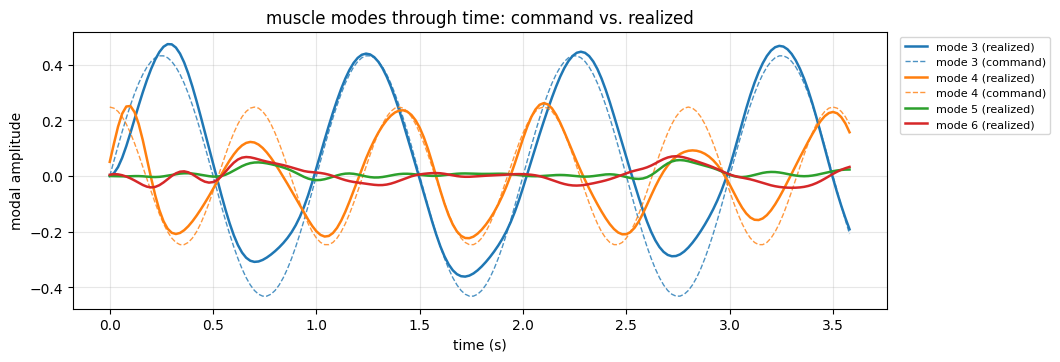

In [13]:
DMD = D_muscles.T @ M @ D_muscles
a_realized = np.array([simkit.project_into_subspace((B @ z) - x_rest, D_muscles, M=M, BMB=DMD).ravel()
                       for z in zs_float])
ts_float = np.arange(N_STEPS_FLOAT) * DT_FLOAT
fig, ax = plt.subplots(figsize=(10.5, 3.6))
for j, k in enumerate(modeset):
    ax.plot(ts_float, a_realized[:, j], color=f"C{j}", lw=1.8, label=f"mode {k} (realized)")
    if AMP_FLOAT[j] != 0:
        ax.plot(ts_float, a_command[:, j], color=f"C{j}", lw=1.0, ls="--", alpha=0.8,
                label=f"mode {k} (command)")
ax.set(xlabel="time (s)", ylabel="modal amplitude", title="muscle modes through time: command vs. realized")
ax.legend(fontsize=8, loc="upper left", bbox_to_anchor=(1.01, 1.0))
ax.grid(alpha=0.3)
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "modal_amplitudes.png"),
                              copy_to=os.path.join(MEDIA_DIR, "025_modal_amplitudes.png"))
plt.show()

## Now let it fall, and let it crawl

On the ground, the external force is the reduced weight `f_gravity`, and `N_CONTACT` boundary
vertices (`simkit.boundary_edges`, then `simkit.farthest_point_sampling`) can touch a floor placed
`GROUND_GAP` below the feet, so the creature first drops and lands. `S_contact` maps $\mathbf z$
to the stacked positions of those contact points.

30 contact points,  ground at y = -0.726


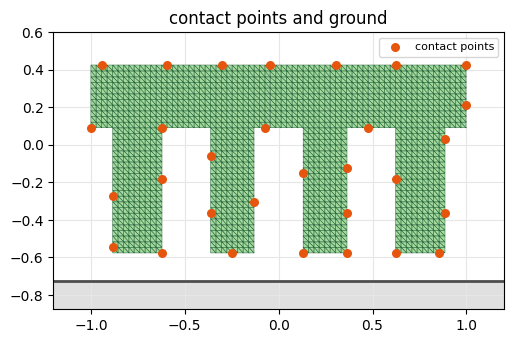

In [14]:
boundary = np.unique(simkit.boundary_edges(T))
contact_idx = np.sort(boundary[simkit.farthest_point_sampling(X[boundary], N_CONTACT)])
S_contact = sp.sparse.kron(simkit.selection_matrix(contact_idx, n), sp.sparse.identity(dim)) @ B
GROUND_Y = float(X[:, 1].min()) - GROUND_GAP
print(f"{len(contact_idx)} contact points,  ground at y = {GROUND_Y:.3f}")

fig, ax = plt.subplots(figsize=(6, 3.6))
utils.plot_mesh(ax, X, T, facecolor=CATERPILLAR_FACE, edgecolor=CATERPILLAR_EDGE, lw=0.3,
                lims=((-1.2, 1.2), (GROUND_Y - 0.15, 0.6)), title="contact points and ground")
ax.scatter(X[contact_idx, 0], X[contact_idx, 1], s=30, color=utils.HANDLE_C, zorder=5, label="contact points")
ax.axhline(GROUND_Y, color="0.3", lw=2)
ax.fill_between([-1.2, 1.2], GROUND_Y - 0.15, GROUND_Y, color="0.88")
ax.legend(loc="upper right", fontsize=8)
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "contact_setup.png"),
                              copy_to=os.path.join(MEDIA_DIR, "025_contact_setup.png"))
plt.show()

### Velocity-level ground contact

Contact is not an energy here; it is a correction inside the global step, in the spirit of
projective dynamics. `ground_contact_force` first takes the unconstrained step $H^{-1}\mathbf f$.
Every contact point that is below the ground and would still move down is **active**: it must end
the step where it started, moved only by the share `1 - FRICTION` of its sliding velocity. The
extra reduced force $\mathbf f_c$ solves $S_a H^{-1}(\mathbf f + \mathbf f_c) = \mathbf p_{\text{target}}$
in the least-squares (or minimum-norm) sense, with $S_a$ the active rows of `S_contact`. With
`FRICTION = 1` a planted foot sticks, so pushing it backwards moves the body forwards.

In [15]:
def ground_contact_force(z, z_curr, f, chol_H, h):
    """Reduced force that stops the active contact points (below the ground, moving down)."""
    z_free = sp.linalg.cho_solve(chol_H, f)                  # the step without contact
    v_free = (S_contact @ (z_free - z_curr) / h).reshape(-1, dim)
    below = (S_contact @ z).reshape(-1, dim)[:, 1] < GROUND_Y
    active = np.where(below & (v_free[:, 1] < 0))[0]
    if len(active) == 0:
        return np.zeros_like(f)
    rows = (dim * active[:, None] + np.arange(dim)).ravel()
    S_a = S_contact[rows]
    S_a_Hinv = sp.linalg.cho_solve(chol_H, S_a.T).T          # how a reduced force moves them
    v_target = np.zeros((len(active), dim))
    v_target[:, 0] = (1 - FRICTION) * v_free[active, 0]      # keep part of the slide, stop the fall
    p_target = (S_a @ z_curr).reshape(-1, dim) + h * v_target
    rhs = p_target.reshape(-1, 1) - S_a_Hinv @ f
    f_contact = np.linalg.lstsq(S_a_Hinv, rhs, rcond=None)[0]
    return f_contact

### Dial in a gait

The gait is `AMP_FRAC`, `PERIODS` and `PHASES` at the top: each muscle gets an amplitude, a period
and a phase. Edit them and re-run to invent new gaits. Phase offsets between the muscles break the
symmetry and turn a wiggle into directed motion. We simulate with gravity and contact and read the
COM straight from the reduced state with `simkit.subspace_com`.

In [16]:
zs_crawl, _ = simulate(N_STEPS_CRAWL, DT_CRAWL, MU_CRAWL, GAMMA_CRAWL, f_gravity,
                       AMP_FRAC, PERIODS, PHASES, contact=ground_contact_force)
crawl_frames = [(B @ z).reshape(n, dim) for z in zs_crawl]
com = np.array([simkit.subspace_com(z, B, X, T, SB=SB).ravel() for z in zs_crawl])
lowest = np.array([(S_contact @ z).reshape(-1, dim)[:, 1].min() for z in zs_crawl]) - GROUND_Y
print(f"crawled {N_STEPS_CRAWL} steps")
print(f"horizontal COM travel: {com[-1, 0] - com[0, 0]:+.3f}")
print(f"vertical COM range:    [{com[:, 1].min():.3f}, {com[:, 1].max():.3f}]  (ground y = {GROUND_Y:.3f})")
print(f"deepest ground penetration: {max(0.0, -lowest.min()):.4f}")

crawled 450 steps
horizontal COM travel: +3.660
vertical COM range:    [-0.142, 0.250]  (ground y = -0.726)
deepest ground penetration: 0.0044


### Center of mass and contact over time

The COM's horizontal coordinate measures locomotion. It rocks back and forth for the first 1.7 s,
gains about three units by $t\approx2.8$ s, slides back a little, and ends in a leap (from
$t\approx4.2$ s the COM rises and every contact point leaves the ground), for a net +3.66, almost
two body lengths toward $+x$. The bottom panel is the contact residual, the height of the lowest
contact point above the ground: it sits at zero while a foot is planted and dips below by at most
0.0044, about one step of fall, because a point is only stopped once it is below.

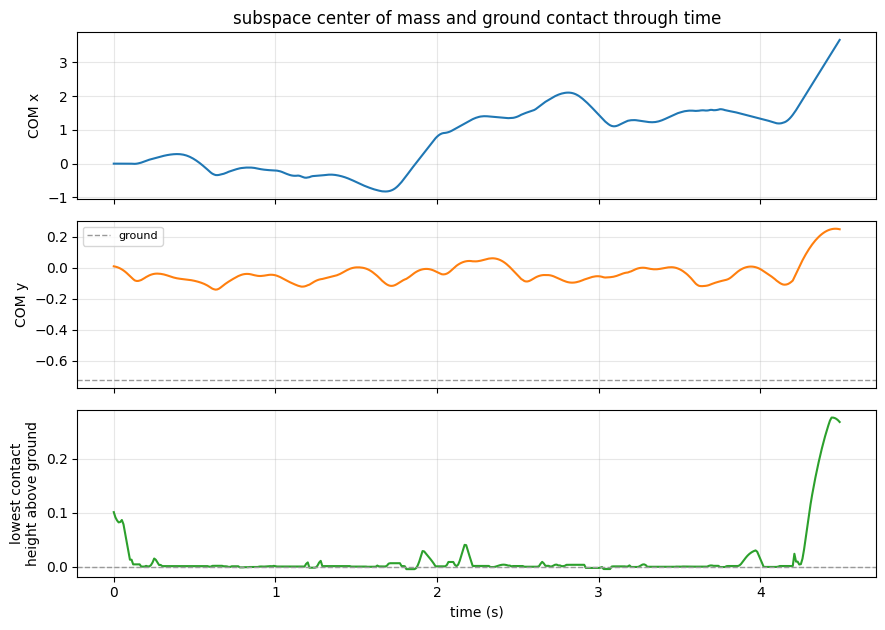

In [17]:
ts_crawl = np.arange(N_STEPS_CRAWL) * DT_CRAWL
fig, axes = plt.subplots(3, 1, figsize=(9, 6.4), sharex=True)
axes[0].plot(ts_crawl, com[:, 0], "C0")
axes[0].set(ylabel="COM x", title="subspace center of mass and ground contact through time")
axes[1].plot(ts_crawl, com[:, 1], "C1")
axes[1].axhline(GROUND_Y, color="0.6", ls="--", lw=1, label="ground")
axes[1].set(ylabel="COM y")
axes[1].legend(fontsize=8)
axes[2].plot(ts_crawl, lowest, "C2")
axes[2].axhline(0, color="0.6", ls="--", lw=1)
axes[2].set(ylabel="lowest contact\nheight above ground", xlabel="time (s)")
for ax in axes:
    ax.grid(alpha=0.3)
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "com.png"),
                              copy_to=os.path.join(MEDIA_DIR, "025_com.png"))
plt.show()

### Watch it crawl

Top: the caterpillar over the floor, with its COM as a red dot. Bottom: the horizontal COM
position drawn in as time advances.

In [18]:
fig, anim = utils.animate_mesh_above_trace(
    crawl_frames[::STRIDE_CRAWL], T, ts_crawl[::STRIDE_CRAWL], {"COM x": com[::STRIDE_CRAWL, 0]},
    markers=com[::STRIDE_CRAWL], floor_y=GROUND_Y, fps=FPS, figsize=(11, 6),
    mesh_face=CATERPILLAR_FACE, mesh_edge=CATERPILLAR_EDGE,
    scene_title="crawling under gravity", xlabel="time (s)", ylabel="COM x")
video = simkit.filesystem.save_animation(anim, os.path.join(RESULTS_DIR, "crawling.mp4"), fps=FPS,
                                         copy_to=os.path.join(MEDIA_DIR, "025_crawling.mp4"))
plt.close(fig)
utils.embed_video(video)

## Optional: optimizing the gait with CMA-ES

The gait above was hand-tuned. `simkit.solvers.cmaes` can instead search the 12 gait parameters
(amplitudes clipped to $[0,1]$, periods to `CMA_PERIOD_RANGE`, free phases) for the largest COM
travel toward $+x$ over a `CMA_ROLLOUT_STEPS`-step rollout, as
`examples/modal_muscles/actuators_a_la_mode_2D.py` in simkit does. It runs many rollouts, so it
is off by default: set `RUN_CMA = True` at the top (needs `pip install cma`).

In [19]:
def negative_travel(params):
    """CMA-ES objective: minus the COM travel toward +x of a short rollout with these gait parameters."""
    amp = np.clip(params[0:4], 0.0, 1.0)
    period = np.clip(params[4:8], *CMA_PERIOD_RANGE)
    phase = params[8:12]
    zs, _ = simulate(CMA_ROLLOUT_STEPS, DT_CRAWL, MU_CRAWL, GAMMA_CRAWL, f_gravity,
                     amp, period, phase, contact=ground_contact_force)
    travel = (simkit.subspace_com(zs[-1], B, X, T, SB=SB) - simkit.subspace_com(z_rest, B, X, T, SB=SB))[0, 0]
    return -travel


if RUN_CMA:
    best, result = simkit.solvers.cmaes(np.concatenate([AMP_FRAC, PERIODS, PHASES]), negative_travel,
                                        maxiter=CMA_GENERATIONS, sigma=CMA_SIGMA, popsize=CMA_POPSIZE,
                                        seed=SEED, return_result=True)
    print("best gait params:", np.round(best, 3))
    print("best forward travel:", round(-result["fbest"], 4))
else:
    print("CMA-ES disabled (set RUN_CMA = True to optimize the gait).")

CMA-ES disabled (set RUN_CMA = True to optimize the gait).


## Takeaways

* A shape's **linear vibration modes** (minus the rigid ones) are a ready-made, rig-free set of
  **muscles**: no painting, no skeleton, no data.
* Activating them sets a **clustered plastic-stretch** target that passive ARAP elasticity and
  inertia resist. `modal_muscle_system` writes it as one energy, minimized by a cheap local/global
  `block_coord` solve inside a 48-dimensional skinning-eigenmode subspace.
* Floating, the muscles reshape the body while its COM stays put. On the ground, sticking contact
  and the same sinusoids with **phase offsets** give a bumpy, leaping gait, and
  `simkit.subspace_com` reads the locomotion straight from the reduced state.
* Edit `AMP_FRAC`, `PERIODS` and `PHASES` to invent gaits, or let CMA-ES search for them; simkit's
  `examples/interactive_demos/014_modal_muscles.py` is a live, slider-driven version.